In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'


tfm = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST(root='/tmp/mnist', train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST(root='/tmp/mnist', train=False, download=True, transform=tfm)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.9MB/s]


In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.f = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10),  # 10개로 출력
        )
        # he 초기화 (ReLu에 아주 적합)
        for m in self.f:
            if isinstance(m, nn.Linear):
                # 만약 m이 선형회귀(nn.Linear)라면
                nn.init.kaiming_normal_(m.weight) # he 초기화
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.f(x)

In [ ]:
model = MLP().to(device)
opt = optim.AdamW(model.parameters(), lr=3e-3)
sched = optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-3, steps_per_epoch=len(train_loader), epochs=5)
crit = nn.CrossEntropyLoss()

In [ ]:
# gradient histor 수집용 (hook)

grads = []
def hook_fn(m, gi, go):
    if isinstance(m, nn.Linear):
        if m.weight.grad is not None:
            grads.append(m.weight.grad.detach().abs().mean().item())

# hooks
hooks = [m.register_full_backward_hook(hook_fn) for m in model.modules() if isinstance(m, nn.Linear)]

In [ ]:
def train_epoch():
    model.train()
    tot = 0
    correct = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        sched.step()

        tot += y.size(0)
        correct += (out.argmax(1)==y).sum().item()
    return loss.item(), correct/tot

In [ ]:
def eval_epoch():
    model.eval()
    tot = 0
    correct = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            tot += y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            # (out.argmax(1)==y) >> True(1) / False(0)
    return correct/tot

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


ep1 loss=0.226 test_acc=0.951
ep2 loss=0.048 test_acc=0.969
ep3 loss=0.009 test_acc=0.980
ep4 loss=0.021 test_acc=0.983
ep5 loss=0.014 test_acc=0.985


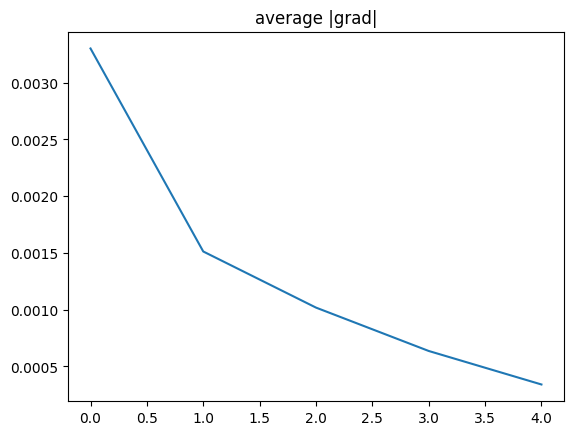

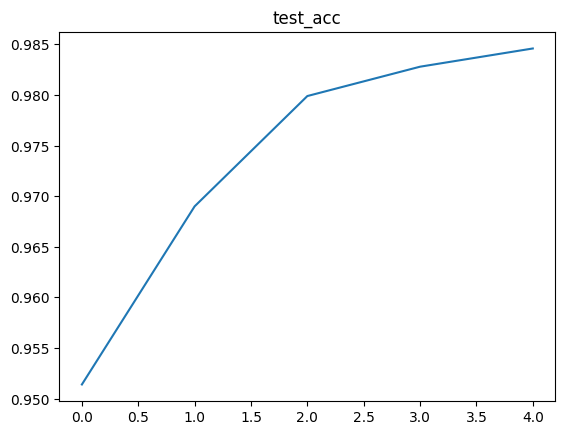

In [ ]:
hist_grad = []
hist_acc = []

for ep in range(5):
    loss, tr_acc = train_epoch()
    acc = eval_epoch()
    hist_grad.append(sum(grads[-len(train_loader):])/max(1, len(train_loader)))
    # -len(train_loader): >> 마지막 에폭의 기울기
    # max(1, len(train_loader)) >> 분모가 0 되면 zero division error 방지
    hist_acc.append(acc)
    print(f'ep{ep+1} loss={loss:.3f} test_acc={acc:.3f}')

plt.figure()
plt.plot(hist_grad)
plt.title('average |grad|')
plt.show()

plt.figure()
plt.plot(hist_acc)
plt.title('test_acc')
plt.show()

for h in hooks:
    h.remove()

보충학습

In [ ]:
# argmax / item

scores = [10, 25, 7, 35]
scores = torch.tensor(scores)
print(scores)
print(scores.argmax())
# 가장 큰 값을 가지고 있는 index 출력
print(scores.argmax().item())

tensor([10, 25,  7, 35])
tensor(3)
3


In [ ]:
out = [
 [0.1, 2.3, 0.5, 1.1],
 [3.2, 0.4, 1.8, 0.9],
 [0.2, 1.1, 4.0, 0.3]
]

out = torch.tensor(out)
out.shape

torch.Size([3, 4])

In [ ]:
out.argmax()

tensor(10)

In [ ]:
out.argmax(1)
# argmax() 가장 큰 값을 가지고 있는 인덱스(위치)
# axis=1

# axis=0(default)
# 각행에서 가장 큰 인덱스 반환

tensor([1, 0, 2])

In [ ]:
# max 와 argmax 차이
out.max() # 가장 큰 값(value)

tensor(4.)

In [ ]:
scores = [10, 25, 7, 35]
scores[-3:]

[25, 7, 35]

In [ ]:
sum(scores[-3:])

67

In [ ]:
sum(scores[-3:]) / 3

22.333333333333332

In [ ]:
len(scores)

4

In [ ]:
sum(scores) / len(scores) # 평균

19.25

In [ ]:
sum(scores[-3:]) / len(scores)

16.75